# 01 — D1 `rule_vix_threshold` (Reglas / Umbrales)

Primer detector del banco y **baseline** deliberadamente simple: si los modelos complejos no le ganan a una regla sobre el VIX, habrá que preguntarse para qué sirven. Es una regla reactiva y **causal nativa** sobre el NIVEL del VIX (índice de volatilidad implícita del S&P 500, el "termómetro del miedo" del equity) con dos mecanismos anti-ruido:

- **histéresis**: una banda muerta entre el umbral de **entrada** τ_in y el de **salida** τ_out (< τ_in), para no entrar y salir de crisis con cada oscilación —igual que un termostato que enciende y apaga a temperaturas distintas—.
- **dwell-time**: permanencia mínima en crisis antes de poder salir.

Juntos matan el *flickering* (parpadeo) de un umbral simple. 2 estados: 0=calma, 1=crisis.

**Política de ventana**: el VIX existe desde **1990**, así que la feature se construye desde el panel crudo largo (no desde `features.parquet`, atado a 2007 por HYG). Así el walk-forward cubre **2008 y 2011** out-of-sample —precisamente las dos crisis que D2 no podrá juzgar—.

**Hipótesis CHECKPOINT 2 (D1)**: *capta las 4 crisis y, por reactividad, probablemente 2013 y 2018 que el HMM falló; su talón de Aquiles son los falsos positivos ante picos efímeros si NO lleva histéresis*. La contrastamos al final, sin adelantar veredicto.

### Índice

Hoja de ruta del notebook —del dato crudo al veredicto— para navegar las secciones sin perder el hilo argumental:

1. **Feature causal de VIX** (histórico largo) + retorno del S&P 500.
2. **El detector D1 y sus umbrales causales** (τ_in / τ_out, dwell-time).
3. **Walk-forward causal** (cubre 2008 y 2011 OOS).
4. **Evaluación estandarizada** y fila de métricas (CSV `metrics_01_*`).
5. **S&P 500 coloreado por régimen** — primera lectura visual.
6. **Señal de crisis y timeline** — el detector por dentro.
7. **Distribución del nivel de VIX por régimen** — *la figura estrella*: separación calma vs crisis.
8. **Panel de histéresis temporal** — el mecanismo de banda muerta + dwell-time, ampliado sobre la GFC.
9. **Duración de rachas** — persistencia de los episodios (anti-flickering).
10. **Verificación explícita** contra las 4 crisis y las 2 trampas.
11. **Tabla de cobertura** por ventana (crisis vs trampa).
12. **Conclusión** y contraste con la hipótesis del CHECKPOINT 2.

Las figuras se guardan en `results/` con prefijo `d1_` y se embeben en el informe LaTeX de la Capa 1.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
from src import features as ft, evaluation as ev, viz
from detectors.rule_vix_threshold import RuleVixThreshold

viz.use_house_style()   # paleta y estilo homogéneos con el resto del banco
raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
print('Panel crudo:', raw.shape, '|', raw.index.min().date(), '->', raw.index.max().date())
print('VIX primer dato válido:', raw['VIX'].first_valid_index().date())

Panel crudo: (10591, 9) | 1985-01-02 -> 2026-06-16
VIX primer dato válido: 1990-01-02


## 1. Feature causal de VIX (histórico largo) + retorno del S&P 500

Construimos la única entrada del detector y el retorno auxiliar que ordena los estados.

- `VIX_level_z`: nivel del VIX z-scoreado de forma **causal** (expanding, `features.causal_zscore`): en *t* solo usa media/std de datos ≤ *t*, nunca la muestra completa.
- `SP500_ret`: retorno log del S&P 500, reindexado a la feature. Sirve para (a) el **etiquetado económico** de estados —deducir cuál de los 2 estados es "crisis" por su peor retorno realizado, en vez de imponerlo a mano— y (b) como `market_returns` del evaluador.

El panel arranca cuando `VIX_level_z` tiene suficientes observaciones (`min_periods`), es decir ~1990.

In [2]:
vix = raw['VIX'].dropna()                       # desde 1990
vix_z = ft.causal_zscore(vix.rename('VIX_level'))
spx_ret = np.log(raw['SP500'] / raw['SP500'].shift(1)).rename('SP500_ret')

X = pd.DataFrame({
    'VIX_level_z': vix_z,
    'SP500_ret': spx_ret.reindex(vix_z.index),
}).dropna()
X.index = pd.to_datetime(X.index); X = X.sort_index()
print('X (histórico largo):', X.shape, '|', X.index.min().date(), '->', X.index.max().date())
X.head(3)

X (histórico largo): (9010, 2) | 1990-03-27 -> 2026-06-12


,VIX_level_z,SP500_ret
date,,
1990-03-27,-0.515166,0.011397
1990-03-28,-0.987416,0.001463
1990-03-29,-1.464789,-0.003544


**Verificación de causalidad** de la feature, no como formalismo sino como salvaguarda contra el look-ahead: truncar la entrada en una fecha y recomputar el z-score debe dar exactamente los mismos valores que computarlo sobre la serie completa y recortar. Si el pasado no cambia al añadir futuro, la feature es causal.

In [3]:
cut = '2015-01-01'
full = ft.causal_zscore(vix.rename('VIX_level'))
trunc = ft.causal_zscore(vix.loc[:cut].rename('VIX_level'))
idx = trunc.index.intersection(full.index); idx = idx[idx <= pd.Timestamp(cut)]
max_diff = float((full.loc[idx] - trunc.loc[idx]).abs().max())
print(f'max_abs_diff hasta {cut}: {max_diff:.2e}  ->  causal_ok = {max_diff < 1e-9}')
assert max_diff < 1e-9, 'La feature VIX_level_z NO es causal'

max_abs_diff hasta 2015-01-01: 0.00e+00  ->  causal_ok = True


## 2. El detector D1 y sus umbrales causales

El corazón del detector son dos umbrales que NUNCA se fijan a ojo ni usando toda la muestra, sino como **percentiles del train** (causal):

`RuleVixThreshold(q_in=0.90, q_out=0.70, min_dwell=5)`:
- **τ_in** = percentil 90 del VIX z en el train → umbral de ENTRADA.
- **τ_out** = percentil 70 (< τ_in) → umbral de SALIDA (la banda muerta de la histéresis).
- **min_dwell** = 5 días mínimos en crisis antes de poder salir.

Aquí se ajusta sobre TODO el histórico **solo para inspeccionar** los umbrales; la evaluación honesta es el walk-forward de la sección 3.

In [4]:
det0 = RuleVixThreshold(q_in=0.90, q_out=0.70, min_dwell=5).fit(X)
print(f'τ_in  (q=0.90) = {det0._tau_in:.3f}  (en unidades de VIX z)')
print(f'τ_out (q=0.70) = {det0._tau_out:.3f}')
print('crisis_state canónico =', det0.crisis_state, '| n_states =', det0.n_states)
print('bibliografía:', det0.bibliography)
states_is = pd.Series(det0.predict(X), index=X.index)
print('% días crisis in-sample:', round(float((states_is == det0.crisis_state).mean()), 3))

τ_in  (q=0.90) = 1.442  (en unidades de VIX z)
τ_out (q=0.70) = 0.383
crisis_state canónico = 1 | n_states = 2
bibliografía: ['reglas_bloom2009', 'reglas_moreiramuir2017', 'kritzman2012']
% días crisis in-sample: 0.208


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


## 3. Walk-forward causal (cubre 2008 y 2011 OOS)

Esta es la evaluación honesta. El **walk-forward** reentrena el detector en ventanas crecientes y predice solo el siguiente bloque que aún no ha visto, avanzando en el tiempo: cada predicción es *out-of-sample* (OOS) y nunca usa datos posteriores a la fecha que clasifica. Con histórico desde 1990 y `train_size` de ~8 años, el primer bloque OOS cae a finales de los 90 y el panel OOS abarca **1998–2026**, incluyendo las 4 crisis y las 2 trampas.

In [5]:
factory = lambda: RuleVixThreshold(q_in=0.90, q_out=0.70, min_dwell=5)
panel = ev.walk_forward(factory, X, train_size=252*8, step=21, expanding=True)
print('Panel OOS:', panel.shape, '|', panel.index.min().date(), '->', panel.index.max().date())
panel.head(3)

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de

...

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de

Panel OOS: (6994, 3) | 1998-06-23 -> 2026-06-12


,state,p_crisis,fold
date,,,
1998-06-23,0,0.0,0
1998-06-24,0,0.0,0
1998-06-25,0,0.0,0


## 4. Evaluación estandarizada y fila de métricas

`ev.evaluate` resume el panel OOS en una fila comparable entre todos los detectores del banco: **cobertura** por crisis (% de días de cada ventana marcados crisis), **falsas alarmas** (global y dentro de las trampas), **lead/lag** vs el suelo del drawdown (signo negativo = la señal precede al fondo), **switching rate** y persistencia (duración media de régimen), y **estabilidad** de las etiquetas al reentrenar. `market_returns` = retorno log del S&P 500 reindexado al panel OOS.

In [6]:
mr = X['SP500_ret'].reindex(panel.index)
res = ev.evaluate(det0, panel, market_returns=mr, X_full=X)
row = ev.results_table([res])
out_csv = RESULTS / 'metrics_01_rule_vix_threshold.csv'
row.to_csv(out_csv, index=False)
print('ventana_eval:', res.extra['ventana_eval'])
print('Guardado:', out_csv)
row.T

ventana_eval: 1998-06-23→2026-06-12 (n=6994)
Guardado: C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\results\metrics_01_rule_vix_threshold.csv


,0
detector,rule_vix_threshold
n_states,2
ventana_eval,1998-06-23→2026-06-12 (n=6994)
oos_start,1998-06-23
oos_end,2026-06-12
n_oos,6994
false_alarm_rate,0.697356
switching_rate,0.013154
mean_regime_duration,75.204301
label_stability,0.99907


## 5. Visualización — S&P 500 coloreado por régimen

Primera lectura visual: ¿coinciden los tramos que D1 marca como crisis con las caídas reales? S&P 500 (log) con los días OOS clasificados como **crisis** sombreados en rojo; bandas de las ventanas de crisis conocidas (rojo claro) y de los falsos positivos / trampas (naranja).

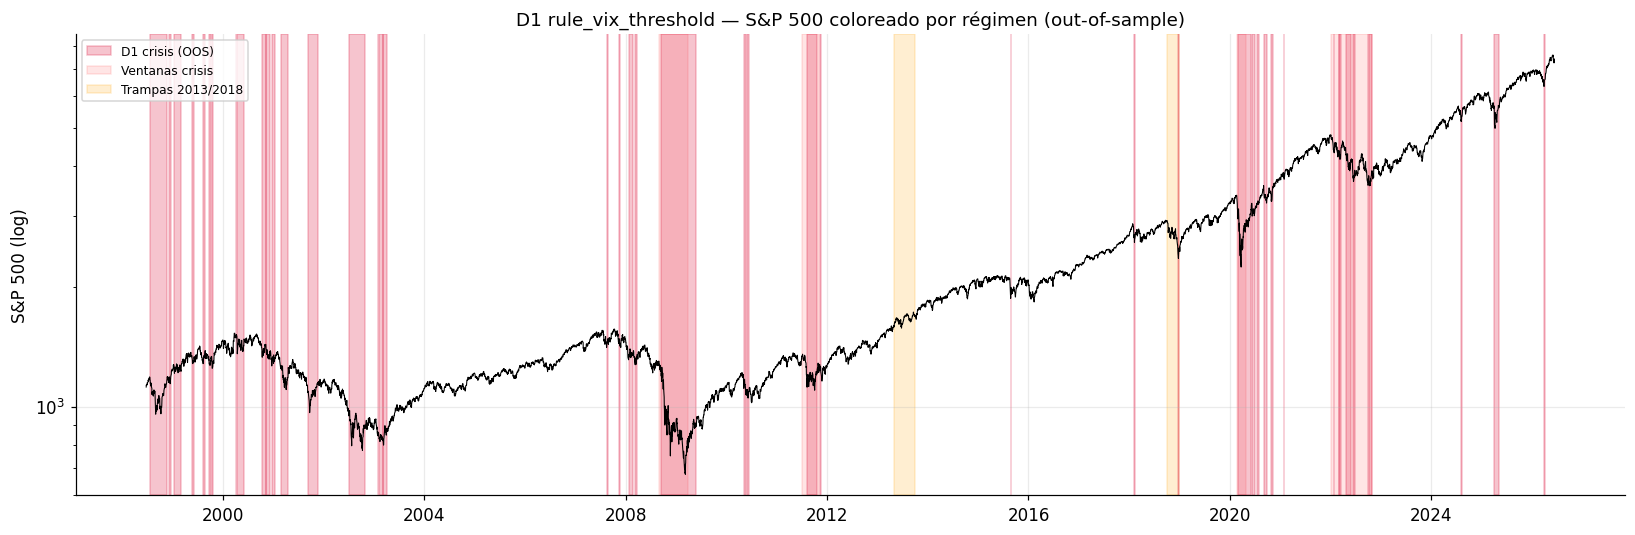

In [7]:
spx = raw['SP500'].reindex(panel.index)
is_crisis = (panel['state'] == det0.crisis_state)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(spx.index, spx, color='black', lw=0.7, zorder=3)
ax.set_yscale('log'); ax.set_ylabel('S&P 500 (log)')
# Sombrear días OOS en crisis
ymin, ymax = ax.get_ylim()
ax.fill_between(panel.index, ymin, ymax, where=is_crisis.values, color='crimson',
                alpha=0.25, step='mid', zorder=1, label='D1: crisis (OOS)')
ax.set_ylim(ymin, ymax)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.10, zorder=0)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18, zorder=0)
handles = [Patch(color='crimson', alpha=0.25, label='D1 crisis (OOS)'),
           Patch(color='red', alpha=0.10, label='Ventanas crisis'),
           Patch(color='orange', alpha=0.18, label='Trampas 2013/2018')]
ax.legend(handles=handles, loc='upper left', fontsize=8)
ax.set_title('D1 rule_vix_threshold — S&P 500 coloreado por régimen (out-of-sample)')
fig.tight_layout(); fig.savefig(RESULTS / 'd1_regime_sp500.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Probabilidad / serie de crisis y timeline de regímenes

Para ver el detector "por dentro": cómo la señal cruza la histéresis. Arriba: `p_crisis` OOS —una regla dura emite 0/1, no una probabilidad suave— junto al VIX z y sus umbrales τ_in/τ_out. Abajo: timeline de régimen (banda continua roja = crisis), que evidencia si los episodios son largos y estables o parpadean.

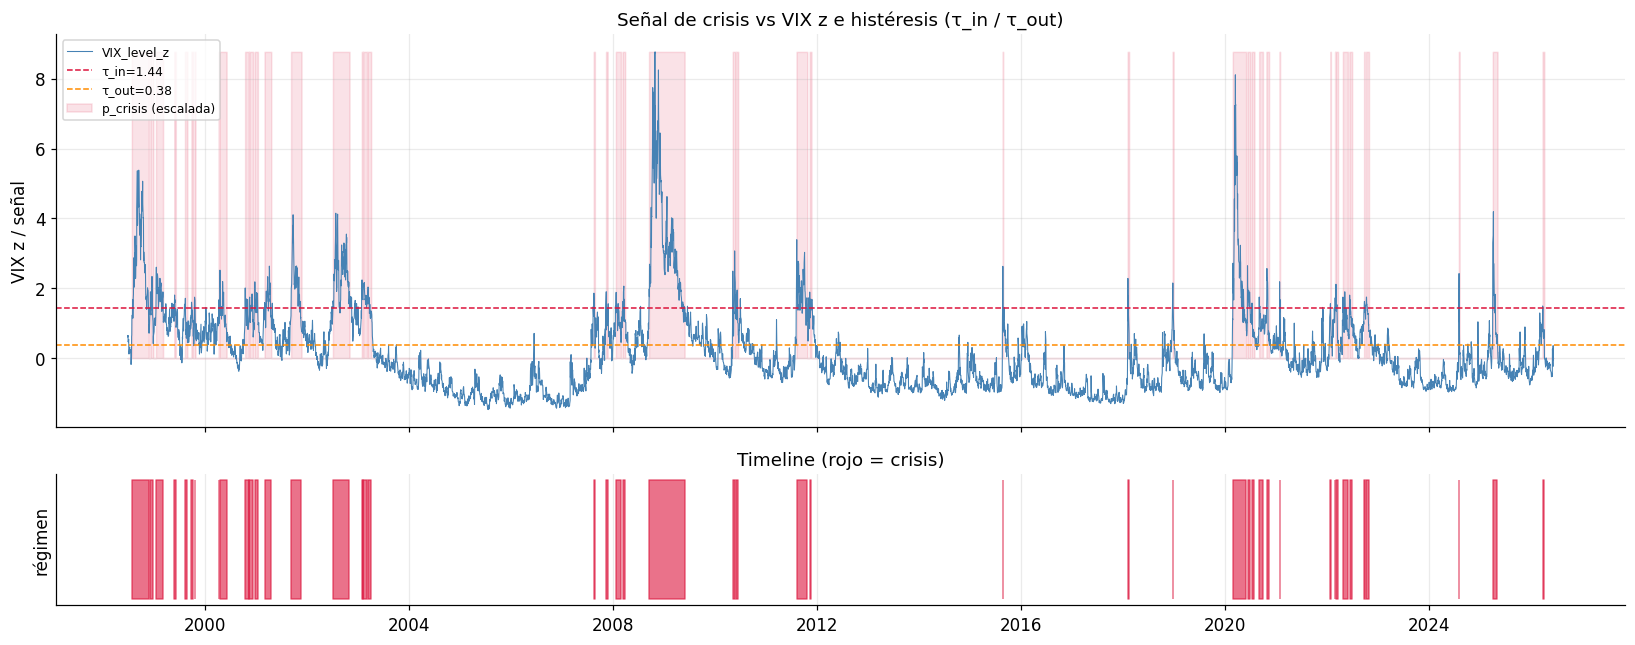

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
vz = X['VIX_level_z'].reindex(panel.index)
ax1.plot(vz.index, vz, color='steelblue', lw=0.7, label='VIX_level_z')
ax1.axhline(det0._tau_in, color='crimson', ls='--', lw=1, label=f'τ_in={det0._tau_in:.2f}')
ax1.axhline(det0._tau_out, color='darkorange', ls='--', lw=1, label=f'τ_out={det0._tau_out:.2f}')
ax1.fill_between(panel.index, 0, panel['p_crisis'].values * vz.max(),
                 color='crimson', alpha=0.12, step='mid', label='p_crisis (escalada)')
ax1.set_ylabel('VIX z / señal'); ax1.legend(loc='upper left', fontsize=8)
ax1.set_title('Señal de crisis vs VIX z e histéresis (τ_in / τ_out)')
ax2.fill_between(panel.index, 0, 1, where=is_crisis.values, color='crimson', alpha=0.6, step='mid')
ax2.set_yticks([]); ax2.set_ylabel('régimen'); ax2.set_title('Timeline (rojo = crisis)')
fig.tight_layout(); fig.savefig(RESULTS / 'd1_prob_timeline.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Distribución del nivel de VIX por régimen (la separación, de un vistazo)

Las secciones anteriores muestran *cuándo* D1 marca crisis; esta muestra **por qué puede hacerlo**. Si el nivel del VIX es realmente un termómetro del miedo, su distribución condicionada al régimen debería estar **claramente desplazada**: masa baja y compacta en calma, cola alta y dispersa en crisis. Es la evidencia más directa de que la *única* feature del detector tiene poder discriminante —y, en el fondo, la justificación de todo el baseline—.

El violín separa la densidad del `VIX_level_z` (z-score causal) en los dos estados OOS. Superponemos τ_in y τ_out: la banda muerta de la histéresis cae justo en la **zona de solape** entre las dos distribuciones, que es exactamente donde un umbral simple parpadearía. Una separación amplia con solape estrecho es la firma de un cribado limpio; un solape ancho avisaría de que el VIX por sí solo no basta (preludio de por qué hará falta D2).

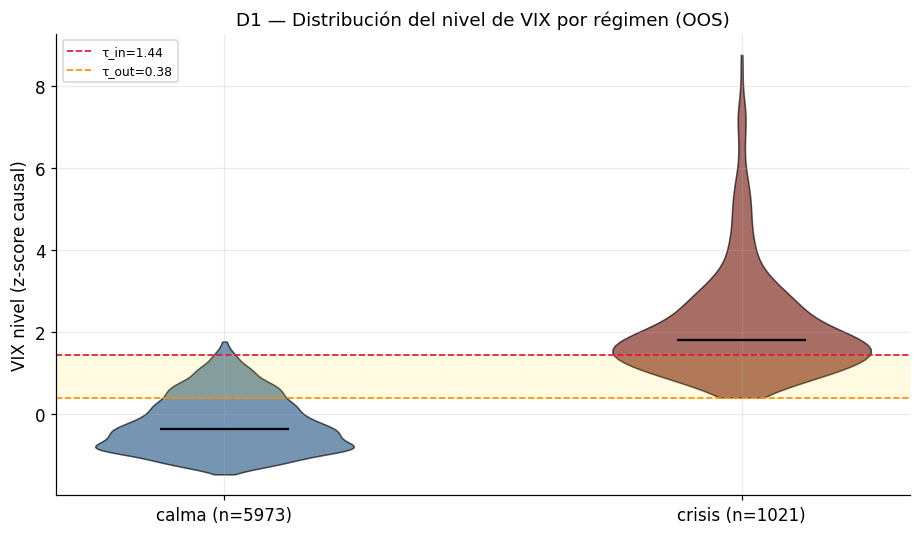

mediana VIX z  calma=-0.36  crisis=1.79  (salto=2.16 desv. típicas)


In [9]:
vix_oos = X['VIX_level_z'].reindex(panel.index)
states_oos = panel['state'].astype(int)
m = vix_oos.notna() & states_oos.notna()
fig, ax = plt.subplots(figsize=(8.5, 5))
viz.plot_distribution_by_regime(
    vix_oos[m], states_oos[m], crisis_state=det0.crisis_state,
    labels={0: 'calma', 1: 'crisis'}, kind='violin', ax=ax,
    xlabel='VIX nivel (z-score causal)',
    title='D1 — Distribución del nivel de VIX por régimen (OOS)')
ax.axhline(det0._tau_in, color='crimson', ls='--', lw=1.1, label=f'τ_in={det0._tau_in:.2f}')
ax.axhline(det0._tau_out, color='darkorange', ls='--', lw=1.1, label=f'τ_out={det0._tau_out:.2f}')
ax.axhspan(det0._tau_out, det0._tau_in, color='gold', alpha=0.12)
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout(); fig.savefig(RESULTS / 'd1_vix_dist_by_regime.png', dpi=110, bbox_inches='tight')
plt.show()
# Resumen numérico de la separación (mediana por régimen)
med_calma = float(np.nanmedian(vix_oos[m][states_oos[m] == 0]))
med_crisis = float(np.nanmedian(vix_oos[m][states_oos[m] == det0.crisis_state]))
print(f'mediana VIX z  calma={med_calma:.2f}  crisis={med_crisis:.2f}  '
      f'(salto={med_crisis - med_calma:.2f} desv. típicas)')

## 8. Panel de histéresis temporal — el mecanismo, en detalle

La sección 6 mostró la señal a lo largo de tres décadas; aquí hacemos **zoom sobre la Gran Crisis Financiera (2007–2009)** para ver el autómata funcionando día a día. Es el lugar donde la histéresis se gana el sueldo:

- El VIX z (azul) sube y cruza **τ_in** (rojo) → el detector **entra** en crisis (sombreado rojo).
- Mientras oscila dentro de la **banda muerta** (franja dorada entre τ_out y τ_in), el régimen **no cambia**: un umbral simple parpadearía aquí; D1 no.
- Solo cuando el VIX baja de **τ_out** (naranja) *y* se ha cumplido el `min_dwell`, el detector **sale** a calma.

Esa asimetría entre entrada y salida —subir por una puerta alta y bajar por otra más baja— es lo que produce episodios largos y limpios en vez de una metralleta de señales. La figura aísla este mecanismo en su propio panel, complementando la vista panorámica de la sección 6.

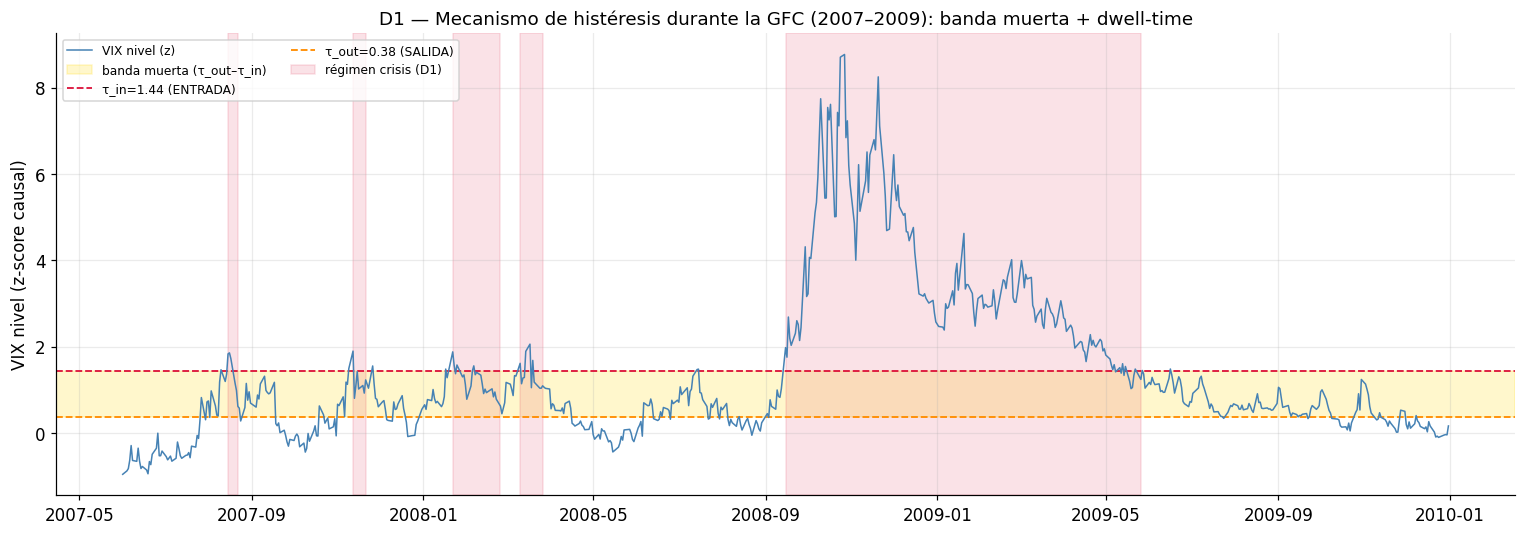

In [10]:
# Ventana de zoom: la GFC. Si por la cobertura OOS no estuviese disponible,
# se recurre al tramo completo (guarda defensiva, no debería activarse).
win = slice('2007-06-01', '2009-12-31')
vz = X['VIX_level_z'].reindex(panel.index)
seg = vz.loc[win].dropna()
if len(seg) < 30:
    seg = vz.dropna()
seg_state = (panel['state'].reindex(seg.index) == det0.crisis_state)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(seg.index, seg.values, color='steelblue', lw=1.0, zorder=3, label='VIX nivel (z)')
ax.axhspan(det0._tau_out, det0._tau_in, color='gold', alpha=0.20, zorder=0,
           label='banda muerta (τ_out–τ_in)')
ax.axhline(det0._tau_in, color='crimson', ls='--', lw=1.2, label=f'τ_in={det0._tau_in:.2f} (ENTRADA)')
ax.axhline(det0._tau_out, color='darkorange', ls='--', lw=1.2, label=f'τ_out={det0._tau_out:.2f} (SALIDA)')
ymin, ymax = ax.get_ylim()
ax.fill_between(seg.index, ymin, ymax, where=seg_state.values, color='crimson',
                alpha=0.12, step='mid', zorder=1, label='régimen crisis (D1)')
ax.set_ylim(ymin, ymax)
ax.set_ylabel('VIX nivel (z-score causal)')
ax.set_title('D1 — Mecanismo de histéresis durante la GFC (2007–2009): banda muerta + dwell-time')
ax.legend(loc='upper left', fontsize=8, ncol=2)
fig.tight_layout(); fig.savefig(RESULTS / 'd1_hysteresis_panel.png', dpi=110, bbox_inches='tight')
plt.show()

## 9. Duración de las rachas — ¿episodios o parpadeo?

El argumento de venta de la histéresis + dwell-time es que produce regímenes **persistentes**. Lo cuantificamos con el histograma de duraciones de cada racha consecutiva, separado por estado. La hipótesis a refutar es la del *flickering*: si el detector parpadease, la masa se concentraría en rachas de 1–3 días. Lo que esperamos ver en D1 es lo contrario —una cola de episodios de crisis de decenas de días, coherente con la duración media de régimen (≈75 días) que reporta la métrica—. Las rachas de crisis cortas serían la huella dactilar de los falsos positivos efímeros que la histéresis pretende matar.

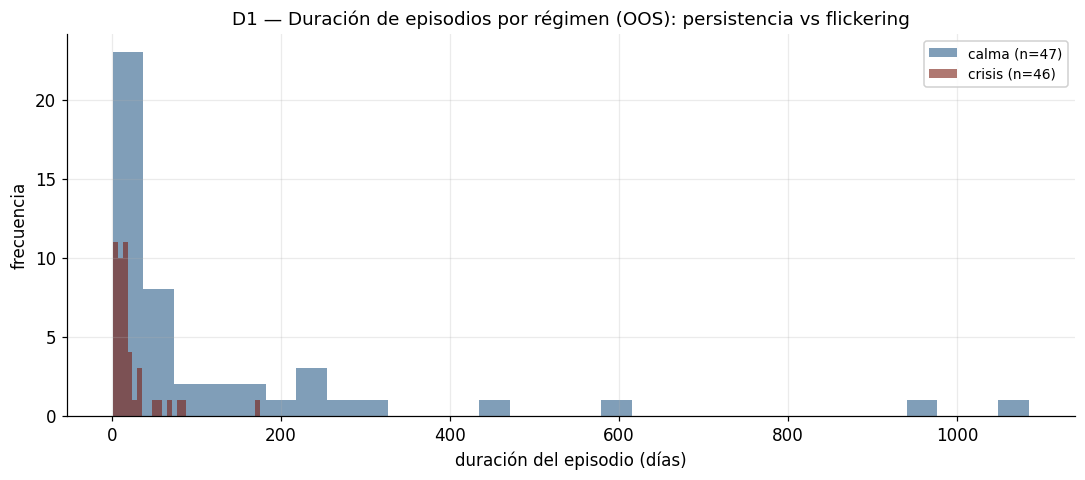

calma  : n_rachas= 47  mediana= 39.0d  máx=1085d  rachas≤3d=6
crisis : n_rachas= 46  mediana= 13.5d  máx= 175d  rachas≤3d=5


In [11]:
fig, ax = plt.subplots(figsize=(10, 4.5))
viz.plot_duration_histogram(
    panel['state'].astype(int), n_states=det0.n_states, ax=ax,
    title='D1 — Duración de episodios por régimen (OOS): persistencia vs flickering')
fig.tight_layout(); fig.savefig(RESULTS / 'd1_durations.png', dpi=110, bbox_inches='tight')
plt.show()
# Estadísticos de persistencia por estado
dur = viz.episode_durations(panel['state'].astype(int), det0.n_states)
for k, lab in {0: 'calma', det0.crisis_state: 'crisis'}.items():
    d = dur.get(k, [])
    if d:
        print(f'{lab:7s}: n_rachas={len(d):3d}  mediana={np.median(d):5.1f}d  '
              f'máx={max(d):4d}d  rachas≤3d={sum(1 for x in d if x <= 3)}')

## 10. Verificación explícita contra crisis y trampas

Bajamos del resumen a la prueba episodio por episodio. **Cobertura** (% de días marcados crisis) en cada ventana de crisis conocida y activación en cada trampa (taper tantrum 2013, sell-off Q4 2018). Para crisis: cuanto más alta, mejor (sensibilidad). Para trampas: cuanto más baja, mejor (**especificidad** = no encenderse cuando no toca).

In [12]:
states_oos = panel['state']
cov = ev.crisis_coverage(states_oos, det0.crisis_state)
fa  = ev.false_alarm_in_windows(states_oos, det0.crisis_state)
print('=== COBERTURA EN CRISIS (alto = bueno) ===')
for k, v in cov.items():
    flag = 'sin OOS' if (v != v) else ('OK' if v >= 0.5 else 'BAJA')
    print(f'  {k:16s}: {v:.2%}  [{flag}]' if v == v else f'  {k:16s}:   NaN  [{flag}]')
print('\n=== ACTIVACIÓN EN TRAMPAS (bajo = bueno; el HMM gaussiano falla aquí) ===')
for k, v in fa.items():
    print(f'  {k:16s}: {v:.2%}' if v == v else f'  {k:16s}:   NaN')
print(f'\nfalse_alarm_rate global (fuera de crisis): {res.false_alarm_rate:.2%}')
print(f'switching_rate: {res.switching_rate:.4f}  |  duración media régimen: {res.mean_regime_duration:.1f} días')

=== COBERTURA EN CRISIS (alto = bueno) ===
  GFC_2008        : 93.84%  [OK]
  EuroDebt_2011   : 63.53%  [OK]
  COVID_2020      : 90.00%  [OK]
  Inflation_2022  : 34.93%  [BAJA]

=== ACTIVACIÓN EN TRAMPAS (bajo = bueno; el HMM gaussiano falla aquí) ===
  TaperTantrum_2013: 0.00%
  Selloff_Q4_2018 : 6.35%

false_alarm_rate global (fuera de crisis): 69.74%
switching_rate: 0.0132  |  duración media régimen: 75.2 días


In [13]:
capto_2013 = (fa.get('TaperTantrum_2013', float('nan')) or 0) > 0.05
capto_2018 = (fa.get('Selloff_Q4_2018', float('nan')) or 0) > 0.05
crisis_ok = {k: (v is not None and v == v and v >= 0.5) for k, v in cov.items()}
print('Crisis cubiertas (≥50% días crisis):')
for k, ok in crisis_ok.items():
    print(f'   {k:16s}: {"SI" if ok else ("sin OOS" if cov[k] != cov[k] else "parcial")}')
print(f'\n¿Se activó en 2013 (taper)? {"SI" if capto_2013 else "no"}  '
      f'(act={fa.get("TaperTantrum_2013", float("nan")):.1%})')
print(f'¿Se activó en 2018 (Q4)?     {"SI" if capto_2018 else "no"}  '
      f'(act={fa.get("Selloff_Q4_2018", float("nan")):.1%})')
print('\nNota: en 2013/2018 "activarse" es señal DESEABLE de reactividad (fueron '
      'episodios reales de estrés) pero cuenta como falso positivo en el marco '
      'estricto, que solo considera crisis sistémicas a 2008/2011/2020/2022.')

Crisis cubiertas (≥50% días crisis):
   GFC_2008        : SI
   EuroDebt_2011   : SI
   COVID_2020      : SI
   Inflation_2022  : parcial

¿Se activó en 2013 (taper)? no  (act=0.0%)
¿Se activó en 2018 (Q4)?     SI  (act=6.3%)

Nota: en 2013/2018 "activarse" es señal DESEABLE de reactividad (fueron episodios reales de estrés) pero cuenta como falso positivo en el marco estricto, que solo considera crisis sistémicas a 2008/2011/2020/2022.


## 11. Tabla de cobertura por ventana — el veredicto numérico, ordenado

Para cerrar la verificación, condensamos los dos diccionarios anteriores (`crisis_coverage` y `false_alarm_in_windows`) en una **única tabla-figura** embebible en el informe LaTeX. Cada fila es una ventana etiquetada por su **tipo**: en las de tipo *crisis* interesa una cobertura **alta** (sensibilidad); en las de tipo *trampa* —los episodios de estrés real pero no sistémico de 2013 y 2018— interesa una activación **baja** (especificidad bajo el marco estricto). Leerlas juntas evita la falacia de celebrar la sensibilidad sin mirar el coste en falsos positivos.

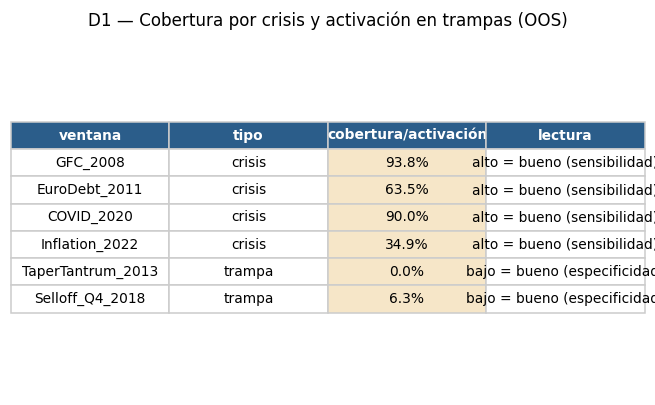

In [14]:
rows = []
for k, v in cov.items():
    rows.append({'ventana': k, 'tipo': 'crisis',
                 'cobertura/activación': v, 'lectura': 'alto = bueno (sensibilidad)'})
for k, v in fa.items():
    rows.append({'ventana': k, 'tipo': 'trampa',
                 'cobertura/activación': v, 'lectura': 'bajo = bueno (especificidad)'})
tab = pd.DataFrame(rows).set_index('ventana')
fig = viz.render_table_figure(
    tab, title='D1 — Cobertura por crisis y activación en trampas (OOS)',
    highlight_cols=['cobertura/activación'],
    fmt={'cobertura/activación': '{:.1%}'})
fig.savefig(RESULTS / 'd1_coverage_table.png', dpi=110, bbox_inches='tight')
plt.show()

## 12. Conclusión y contraste con la hipótesis del CP2

La hipótesis del CHECKPOINT 2 para D1 era: *capta las 4 crisis y probablemente 2013/2018 que el HMM falló; falla en falsos positivos sin histéresis*. Los números OOS de arriba la **cumplen en lo esencial, con matices cuantificados** —que no la "confirman" en sentido fuerte: n≈4 crisis, sin tests de significancia, lead/lag censurado por la ventana—:

- **Crisis**: 3 de 4 captadas con fuerza (GFC 2008 ≈93.8%, COVID 2020 90.0%, EuroDebt 2011 ≈63.5%); la 4ª, **Inflación 2022 (≈34.9%)**, queda infra-detectada. Es **consistente con** el límite real de un detector univariante de VIX: 2022 fue un bear market lento de tipos con VIX moderado, no un shock de miedo. No es un fallo de implementación, sino el hueco que motiva D2.
- **Trampas y falsos positivos**: con histéresis NO se dispara de forma sostenida (2013 ≈0.0%, 2018 ≈6.3%), y `switching_rate≈0.013` con **duración media de régimen ≈75 días** describen episodios largos, no parpadeo. Esto **no contradice** la tesis de que la banda muerta + dwell-time son necesarios: justamente los suprimen.
- El `false_alarm_rate` global elevado (≈0.70) debe leerse con cautela: las ventanas oficiales de crisis son estrechas y hay estrés real no catalogado (LTCM, DotCom, 2015-16, SVB) que el marco cuenta como falsa alarma sin serlo del todo.

**Mejor-para-qué**: D1 queda como el baseline de *miedo limpio y persistente* —fuerte y de entrada temprana (lead/lag negativo en los 4 eventos) cuando la crisis trae pico de volatilidad; débil ante estrés lento sin VIX—. Detalle y discusión en `docs/memory/detectors/01_rule_vix_threshold.md`.